# Checkpoint 3: Alternative Model — Random Forest Regressor

**Fahed (Dan) Geravi**

This version includes improved feature engineering, cleaner plot output, saved figures, and `%matplotlib inline` so visuals display properly in Jupyter/VS Code notebooks.


In [7]:
%matplotlib inline

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

print("Libraries loaded successfully.")


Libraries loaded successfully.


## Load and Parse Lap Data

In [8]:
file_path = Path("data/raw/lap_times_2023_3_5343.json")
figures_dir = Path("../figures")
figures_dir.mkdir(parents=True, exist_ok=True)

with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

rows = []

for driver_entry in data["laps"]:
    driver_name = driver_entry.get("FullName")

    for lap_entry in driver_entry.get("Laps", []):
        rows.append({
            "Driver": driver_name,
            "Lap": lap_entry.get("Lap"),
            "LapTime": lap_entry.get("LapTime"),
            "LapSpeed": lap_entry.get("LapSpeed"),
            "RunningPos": lap_entry.get("RunningPos")
        })

df = pd.DataFrame(rows)

print("Raw shape:", df.shape)
df.head()


Raw shape: (2575, 5)


,Driver,Lap,LapTime,LapSpeed,RunningPos
0,Zane Smith,0,NaN,NaN,15
1,Zane Smith,1,53.922,166.908,16
2,Zane Smith,2,53.343,168.719,18
3,Zane Smith,3,121.309,74.191,18
4,Zane Smith,4,129.723,69.379,17


## Clean Data

In [9]:
for col in ["Lap", "LapTime", "LapSpeed", "RunningPos"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["Driver", "Lap", "LapTime", "LapSpeed", "RunningPos"]).copy()

df = df[df["Lap"] > 0].copy()
df = df[(df["LapTime"] < 100) & (df["LapSpeed"] > 100)].copy()

# Remove extreme outliers that may represent pit laps, cautions, or bad data
df = df[df["LapTime"] < df["LapTime"].quantile(0.99)].copy()
df = df[df["LapSpeed"] > df["LapSpeed"].quantile(0.01)].copy()

df = df.sort_values(["Driver", "Lap"]).reset_index(drop=True)

print("Cleaned shape:", df.shape)
df.head()


Cleaned shape: (1222, 5)


,Driver,Lap,LapTime,LapSpeed,RunningPos
0,Ben Rhodes,1,53.211,169.138,19
1,Ben Rhodes,2,52.852,170.287,17
2,Ben Rhodes,7,85.951,104.711,16
3,Ben Rhodes,11,51.798,173.752,16
4,Ben Rhodes,12,49.093,183.326,20


## Feature Engineering

In [10]:
encoder = LabelEncoder()
df["DriverID"] = encoder.fit_transform(df["Driver"])

# Difference from previous lap for each driver
df["LapTimeDiff"] = df.groupby("Driver")["LapTime"].diff().fillna(0)
df["SpeedDiff"] = df.groupby("Driver")["LapSpeed"].diff().fillna(0)

# Rolling averages over last 5 laps
df["AvgLapTimeLast5"] = (
    df.groupby("Driver")["LapTime"]
      .transform(lambda x: x.rolling(5, min_periods=1).mean())
)

df["AvgSpeedLast5"] = (
    df.groupby("Driver")["LapSpeed"]
      .transform(lambda x: x.rolling(5, min_periods=1).mean())
)

# Rolling consistency measure
df["LapTimeStdLast5"] = (
    df.groupby("Driver")["LapTime"]
      .transform(lambda x: x.rolling(5, min_periods=1).std())
      .fillna(0)
)

# Driver-level pace averages
df["DriverAvgLapTime"] = df.groupby("Driver")["LapTime"].transform("mean")
df["DriverAvgSpeed"] = df.groupby("Driver")["LapSpeed"].transform("mean")

df.head()


,Driver,Lap,LapTime,LapSpeed,RunningPos,DriverID,LapTimeDiff,SpeedDiff,AvgLapTimeLast5,AvgSpeedLast5,LapTimeStdLast5,DriverAvgLapTime,DriverAvgSpeed
0,Ben Rhodes,1,53.211,169.138,19,0,0.000,0.000,53.211000,169.138000,0.000000,53.1192,173.678175
1,Ben Rhodes,2,52.852,170.287,17,0,-0.359,1.149,53.031500,169.712500,0.253851,53.1192,173.678175
2,Ben Rhodes,7,85.951,104.711,16,0,33.099,-65.576,64.004667,148.045333,19.006930,53.1192,173.678175
3,Ben Rhodes,11,51.798,173.752,16,0,-34.153,69.041,60.953000,154.472000,16.676119,53.1192,173.678175
4,Ben Rhodes,12,49.093,183.326,20,0,-2.705,9.574,58.581000,160.242800,15.385110,53.1192,173.678175


## Define Features and Target

In [11]:
features = [
    "DriverID",
    "Lap",
    "LapTime",
    "LapSpeed",
    "LapTimeDiff",
    "SpeedDiff",
    "AvgLapTimeLast5",
    "AvgSpeedLast5",
    "LapTimeStdLast5",
    "DriverAvgLapTime",
    "DriverAvgSpeed"
]

X = df[features]
y = df["RunningPos"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])


Training rows: 977
Testing rows: 245


## Hyperparameter Tuning with Grid Search

In [12]:
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

model = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)
print("Best CV R²:", f"{grid_search.best_score_:.4f}")


Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best parameters: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
Best CV R²: 0.7688


## Model Evaluation

In [13]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("Random Forest Training Metrics")
print(f"  R²:   {train_r2:.4f}")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  MAE:  {train_mae:.4f}")

print()
print("Random Forest Testing Metrics")
print(f"  R²:   {test_r2:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAE:  {test_mae:.4f}")


Random Forest Training Metrics
  R²:   0.9723
  RMSE: 1.6179
  MAE:  1.1580

Random Forest Testing Metrics
  R²:   0.8364
  RMSE: 3.9307
  MAE:  2.8033


## Cross-Validation on Full Dataset

In [14]:
cv_scores = cross_val_score(model, X, y, cv=5, scoring="r2")

print("5-Fold CV R² scores:", cv_scores)
print(f"Mean CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


5-Fold CV R² scores: [ 0.07463626 -0.63133477  0.58270263 -0.4402219   0.0917055 ]
Mean CV R²: -0.0645 ± 0.4301


## Feature Importances

             Feature  Importance
10    DriverAvgSpeed    0.226790
0           DriverID    0.151102
1                Lap    0.118657
9   DriverAvgLapTime    0.107854
8    LapTimeStdLast5    0.097915
2            LapTime    0.061835
3           LapSpeed    0.059354
6    AvgLapTimeLast5    0.056323
7      AvgSpeedLast5    0.048095
5          SpeedDiff    0.036774
4        LapTimeDiff    0.035301


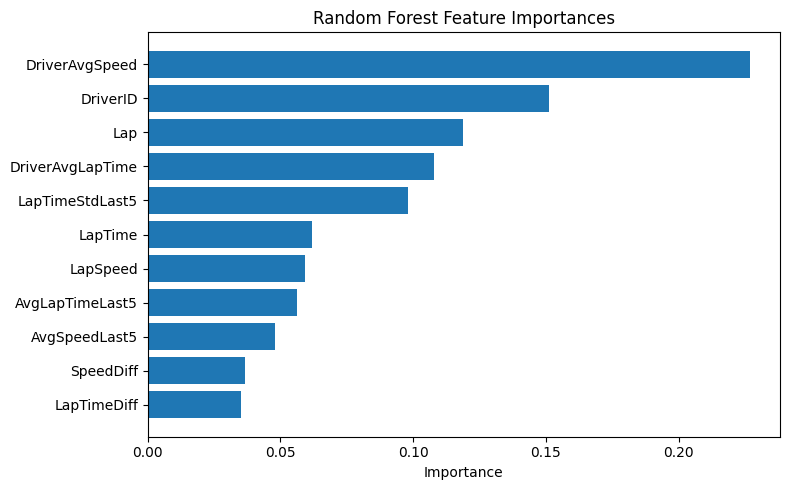

In [15]:
feat_imp = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=True)

print(feat_imp.sort_values("Importance", ascending=False))

plt.figure(figsize=(8, 5))
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.xlabel("Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.savefig(figures_dir / "rf_feature_importance_improved.png", dpi=300, bbox_inches="tight")
plt.show()


## Predicted vs Actual

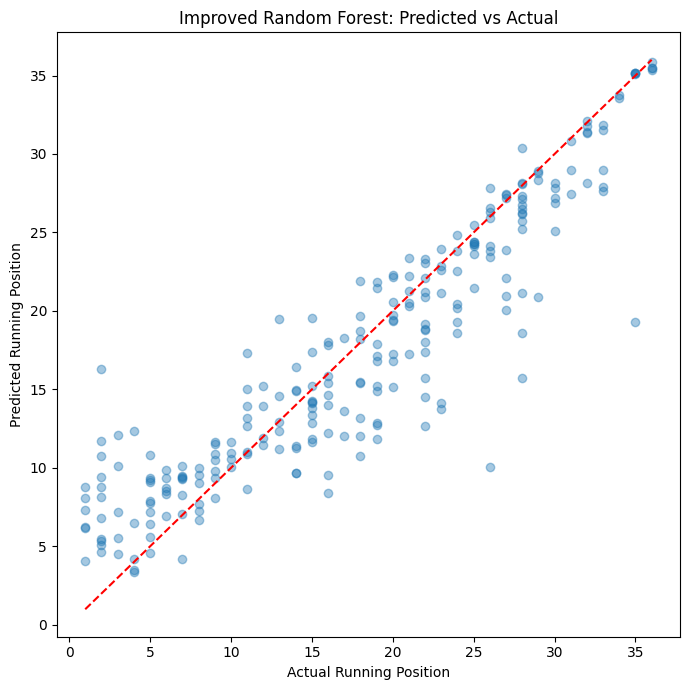

In [16]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_test_pred, alpha=0.4)

mn = min(y_test.min(), y_test_pred.min())
mx = max(y_test.max(), y_test_pred.max())

plt.plot([mn, mx], [mn, mx], "r--")
plt.xlabel("Actual Running Position")
plt.ylabel("Predicted Running Position")
plt.title("Improved Random Forest: Predicted vs Actual")
plt.tight_layout()
plt.savefig(figures_dir / "rf_predicted_vs_actual_improved.png", dpi=300, bbox_inches="tight")
plt.show()


## Residual Plot

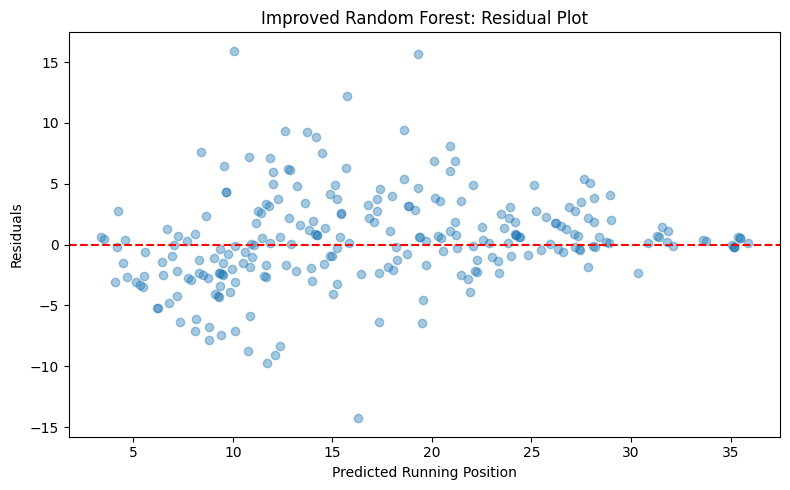

In [17]:
residuals = y_test - y_test_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred, residuals, alpha=0.4)
plt.axhline(0, color="r", linestyle="--")
plt.xlabel("Predicted Running Position")
plt.ylabel("Residuals")
plt.title("Improved Random Forest: Residual Plot")
plt.tight_layout()
plt.savefig(figures_dir / "rf_residual_plot_improved.png", dpi=300, bbox_inches="tight")
plt.show()


## Residual Histogram

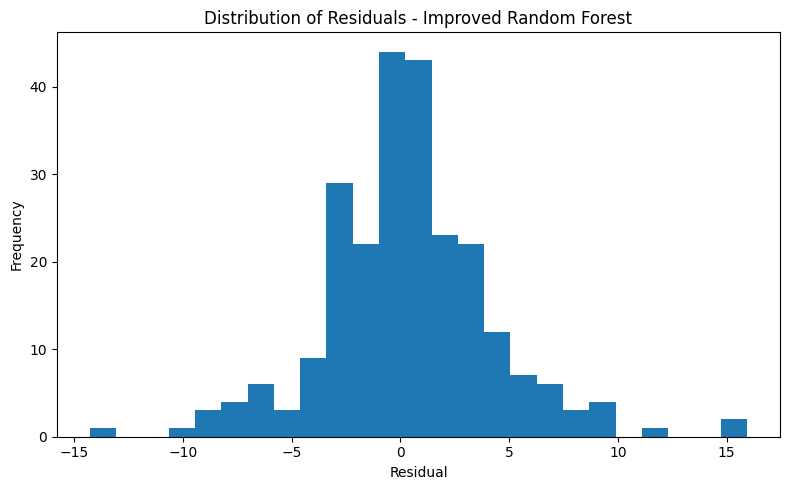

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=25)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals - Improved Random Forest")
plt.tight_layout()
plt.savefig(figures_dir / "rf_residual_histogram_improved.png", dpi=300, bbox_inches="tight")
plt.show()


## Optional Gradient Boosting Comparison

In [19]:
boost_model = HistGradientBoostingRegressor(random_state=42)
boost_model.fit(X_train, y_train)

boost_pred = boost_model.predict(X_test)

boost_r2 = r2_score(y_test, boost_pred)
boost_rmse = np.sqrt(mean_squared_error(y_test, boost_pred))
boost_mae = mean_absolute_error(y_test, boost_pred)

print("Gradient Boosting Testing Metrics")
print(f"  R²:   {boost_r2:.4f}")
print(f"  RMSE: {boost_rmse:.4f}")
print(f"  MAE:  {boost_mae:.4f}")


Gradient Boosting Testing Metrics
  R²:   0.8626
  RMSE: 3.6022
  MAE:  2.6694


## Summary Comparison

In [20]:
print("=" * 75)
print(f"{'Metric':<25} {'Linear Reg':>15} {'Improved RF':>15} {'Gradient Boost':>15}")
print("=" * 75)
print(f"{'Train R²':<25} {'0.0594':>15} {train_r2:>15.4f} {'N/A':>15}")
print(f"{'Test R²':<25} {'0.0350':>15} {test_r2:>15.4f} {boost_r2:>15.4f}")
print(f"{'Train RMSE':<25} {'9.2628':>15} {train_rmse:>15.4f} {'N/A':>15}")
print(f"{'Test RMSE':<25} {'9.9565':>15} {test_rmse:>15.4f} {boost_rmse:>15.4f}")
print(f"{'Train MAE':<25} {'7.9375':>15} {train_mae:>15.4f} {'N/A':>15}")
print(f"{'Test MAE':<25} {'8.7068':>15} {test_mae:>15.4f} {boost_mae:>15.4f}")
print("=" * 75)

print()
print("Saved figures to:", figures_dir.resolve())


Metric                         Linear Reg     Improved RF  Gradient Boost
Train R²                           0.0594          0.9723             N/A
Test R²                            0.0350          0.8364          0.8626
Train RMSE                         9.2628          1.6179             N/A
Test RMSE                          9.9565          3.9307          3.6022
Train MAE                          7.9375          1.1580             N/A
Test MAE                           8.7068          2.8033          2.6694

Saved figures to: /Users/fgeravi/Desktop/figures


In [21]:
from pathlib import Path

print(Path.cwd())

/Users/fgeravi/Desktop/NascarPROJ


In [22]:
from pathlib import Path

for p in Path.cwd().rglob("*.json"):
    print(p)

/Users/fgeravi/Desktop/NascarPROJ/data/raw/weekend-feed-5392.json
/Users/fgeravi/Desktop/NascarPROJ/data/raw/lap_times_2023_3_5343.json
/Users/fgeravi/Desktop/NascarPROJ/.venv/share/jupyter/kernels/python3/kernel.json
/Users/fgeravi/Desktop/NascarPROJ/.venv/lib/python3.13/site-packages/decorator-5.2.1.dist-info/pbr.json
/Users/fgeravi/Desktop/NascarPROJ/.venv/lib/python3.13/site-packages/scipy/stats/tests/data/studentized_range_mpmath_ref.json
/Users/fgeravi/Desktop/NascarPROJ/.venv/lib/python3.13/site-packages/debugpy/_vendored/pydevd/_pydevd_bundle/_debug_adapter/debugProtocol.json
/Users/fgeravi/Desktop/NascarPROJ/.venv/lib/python3.13/site-packages/debugpy/_vendored/pydevd/_pydevd_bundle/_debug_adapter/debugProtocolCustom.json
